In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT --> Temperature
# V --> vaccum
# AP --> pressure
# RH --> humidity

# PE --> produced energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [7]:
# Split out Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [8]:
df.shape

(9568, 5)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [10]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]])

In [12]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
# pandas series to tensor 1D to 2D. -1 means all the row slect with column 1

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [13]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor) # here also create pair and access data from ram
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [14]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [15]:
#Define Our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(

            #1st Hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            #2nd hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),

            #Output Layer
            nn.Linear(6,1),
        )

    def forward(self, x):
        return self.model(x)

In [16]:
import torch.optim as optim

model = ANN()

#loss Optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())


# Training the ANN

In [17]:
epochs = 100
train_losses = []
val_losses = []
best_val_loss = float("inf")


for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #total training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch, xy= label of 1 batch

        optimizer.zero_grad() # gradient 

        outputs = model(xb) # forward prop.... predicting outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop... compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    #Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss =  running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & validation loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1/100 ==> train loss = 205473.13046875 & validation loss = 202927.671875
epoch 2/100 ==> train loss = 194373.23528645834 & validation loss = 180760.171875
epoch 3/100 ==> train loss = 156058.19983723958 & validation loss = 126607.453125
epoch 4/100 ==> train loss = 95143.46129557291 & validation loss = 66703.7734375
epoch 5/100 ==> train loss = 47613.54795735677 & validation loss = 34253.07421875
epoch 6/100 ==> train loss = 27387.428080240887 & validation loss = 22818.955078125
epoch 7/100 ==> train loss = 19867.95917561849 & validation loss = 17599.724609375
epoch 8/100 ==> train loss = 15591.785229492187 & validation loss = 13775.62890625
epoch 9/100 ==> train loss = 12133.501245117188 & validation loss = 10464.603515625
epoch 10/100 ==> train loss = 9097.730967203775 & validation loss = 7664.28955078125
epoch 11/100 ==> train loss = 6521.644827270507 & validation loss = 5362.1015625
epoch 12/100 ==> train loss = 4441.037995402018 & validation loss = 3549.158935546875
epoch 13

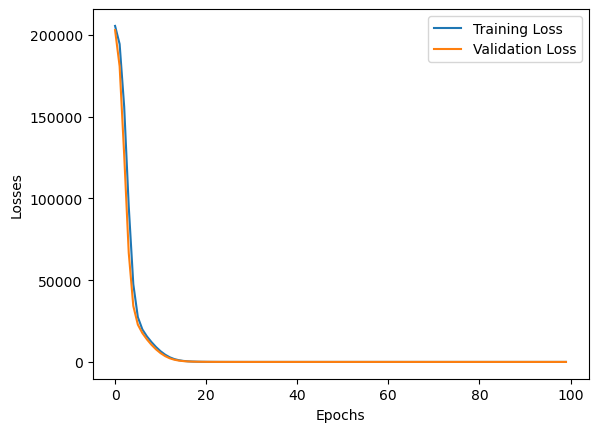

In [18]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [19]:
# Loading the best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [20]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds  = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 19.646991729736328
Testing MSE: 18.158876419067383


In [21]:
from sklearn.metrics import r2_score

print("r2 score in Test data: ",r2_score(y_test, test_preds) )

r2 score in Test data:  0.9365394088637626


In [22]:
# Compare with actual and predicted value
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)


,Predicted Values,Actual Values
0,435.704102,433.27
1,436.236298,438.16
2,461.002716,458.42
3,476.758453,480.82
4,435.223602,441.41
...,...,...
1909,451.426117,456.70
1910,431.312012,438.04
1911,468.102264,467.80
1912,430.627625,437.14
